# Inspecting the PyDoseRT pencil-beam model
**Author:** Attila Simkó

This example shows one of the core ingredients behind PyDoseRT dose calculations: the pencil-beam model.

We will:

1. Initialize a pencil-beam model,
2. Evaluate how the beam kernel changes with depth,
3. Visualize depth-dependent kernel profiles.

This is not a full dose-calculation workflow. Instead, it gives a compact view of the depth and lateral behavior used by the model.

In [1]:
try:
    import pydosert
    print("pydosert is already installed")
except ImportError:
    !pip install pydosert

import numpy as np
import matplotlib.pyplot as plt
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import pydosert as PDRT

pydosert is already installed


## Initialize the pencil-beam model

The pencil-beam model describes how dose spreads laterally and changes with depth.
We choose:

- `resolution`: voxel spacing used by the kernel,
- `kernel_size`: lateral size of the computed kernel,
- `tpr_20_10`: beam-quality parameter from the machine model.

We then evaluate kernels for a range of depths in water.

In [2]:
kernels = []

kernel_size = 65
resolution = (1.0, 1.0, 1.0)
tpr_20_10 = 0.72

pbm = PDRT.physics.PencilBeamModel(resolution=resolution,
                                   tpr_20_10=tpr_20_10, 
                                   kernel_size=kernel_size
)

depths = np.arange(0.0, 200.0, 1.0)
for depth in depths:
    kernels.append(pbm.get_nested_kernels(torch.from_numpy(np.array([[[depth]]]))))

kernels = np.stack(kernels, 0)[:, 0, 0, :, :]

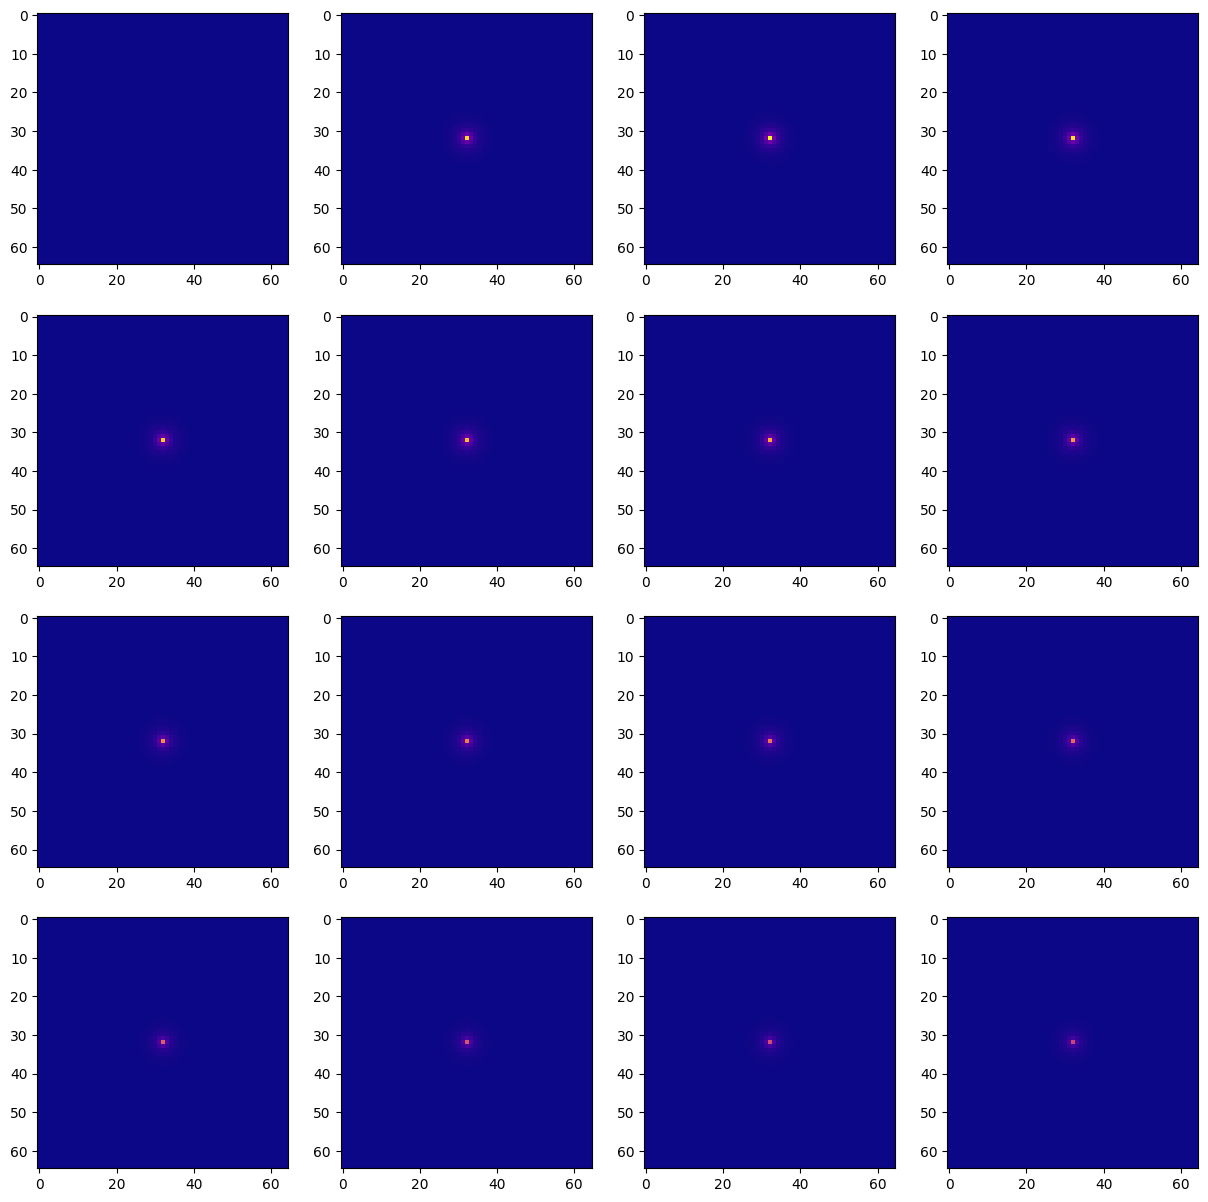

In [3]:
# Visualize the kernels for a quick insight into depth-dependence
plt.figure(figsize=(15, 15))
for i in range(16):
    kernel_idx = int(i * kernels.shape[0] / 16)
    plt.subplot(4, 4, i+1)
    plt.imshow(kernels[kernel_idx, :, :], vmin=0, vmax=kernels.max(), cmap='plasma')
plt.show()

## Inspect depth-dependent terms

These curves show depth-dependent components used by the pencil-beam model.

They help explain why the kernel shape and width change as the beam travels deeper into the phantom.

The components are described in depth by [Nyholm et al. 2006](https://www.sciencedirect.com/science/article/abs/pii/S0167814006000466)

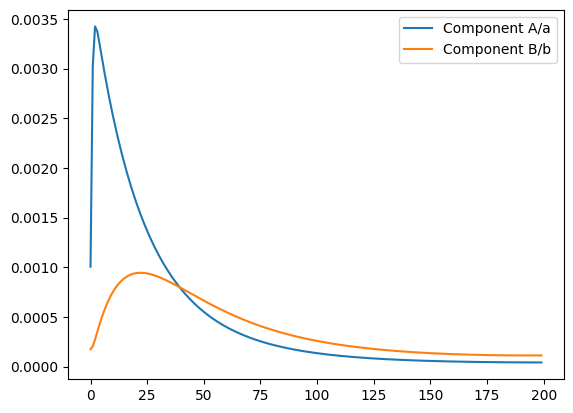

In [4]:
plt.plot(depths, pbm.depth_A_per_a(torch.from_numpy(depths)), label="Component A/a")
plt.plot(depths, pbm.depth_B_per_b(torch.from_numpy(depths)), label="Component B/b")
plt.legend()

## Compare lateral profiles at different depths

Finally, we compare 1D kernel cross-sections at two depths.

This gives a simple way to see how the pencil-beam kernel evolves with depth.

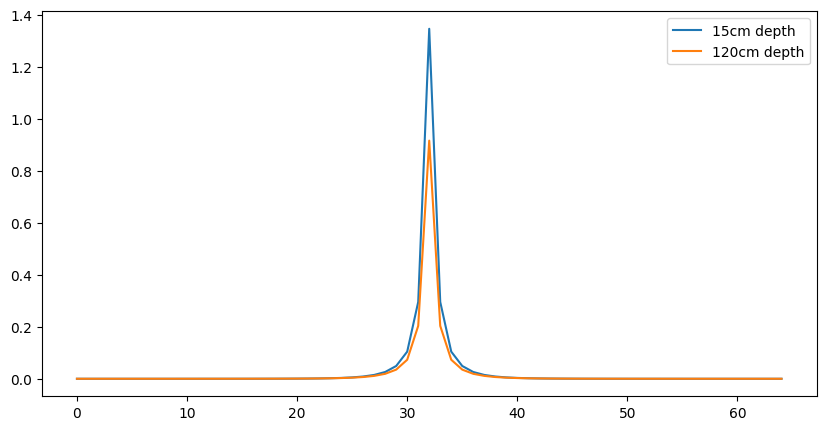

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(kernels[15, kernel_size // 2, :], label="15cm depth")
plt.plot(kernels[120, kernel_size // 2, :], label="120cm depth")
plt.legend()